In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M01_F10_K004_16.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M07_F04_K004_8.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M07_F10_K004_2.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N09_M07_F10_K004_2.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N09_M07_F10_K004_7.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M01_F10_K004_8.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M07_F10_K004_12.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M01_F10_K004_20.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M01_F10_K004_1.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N09_M07_F10_K004_3.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N09_M07_F10_K004_8.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/K004.pdf
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M07_F04_K004_9.mat
/kaggle/input/datasets/dippatel03/pa

In [2]:
import numpy as np
import pandas as pd
import os
import glob
from tqdm.notebook import tqdm
from scipy.io import loadmat

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-03-20 07:46:44.937482: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773992805.175005      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773992805.243643      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773992805.794432      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773992805.794464      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773992805.794467      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
#Configuration

INPUT_PATH   = '/kaggle/input/datasets/dippatel03/paderborn-db'
WINDOW_SIZE  = 1024   # samples per segment (1024 @ 64kHz ≈ 16 ms)
STRIDE       = 512    # 50% overlap → doubles dataset size
FILES_PER_FOLDER = 20 # default 

BATCH_SIZE   = 64
EPOCHS       = 50    # EarlyStopping will cut this short
LEARNING_RATE = 1e-3

# USE_RESIDUAL = False

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("Configuration set.")

Configuration set.


In [ ]:
# def check_size(base_path, files_per_folder=5):
#     folders = ['K001']
#     sizes = []

#     print(f"Found {len(folders)} class folders: {folders}\n")

#     for folder in folders:
#         folder_path = os.path.join(base_path, folder)
#         files = sorted(glob.glob(os.path.join(folder_path, "*.mat")))

#         for file_path in files[:files_per_folder]:
#             print(f"\n📂 File: {file_path}")

#             mat_data = loadmat(file_path)

#             for key in mat_data.keys():
#                 if key.startswith("__"):
#                     continue

#                 try:
#                     data = mat_data[key][0, 0]['Y'][0, 0]['Data']
#                     data_arr = np.array(data).flatten().astype(np.float32)

#                     print(f"✅ Key: {key} → shape: {data_arr.shape}")
#                     sizes.append(data_arr.shape)

#                 except Exception as e:
#                     print(f"❌ Key: {key} → Error: {e}")

#     return sizes

# size = check_size(INPUT_PATH)
# print(size)

In [4]:
def extract_paderborn_signal(mat_content):
    """
    Extracts the vibration signal from Paderborn .mat files.
    Structure: mat['FileName'][0,0]['Y'][0,0]['Data']
    Falls back to largest array if structure differs.
    """
    for key in mat_content.keys():
        if key.startswith('__'):
            continue
        try:
            data = mat_content[key][0, 0]['Y'][0, 0]['Data']
            return np.array(data).flatten().astype(np.float32)
        except (IndexError, KeyError, TypeError):
            data_array = np.array(mat_content[key])
            return data_array.flatten().astype(np.float32)
    return None


def load_paderborn_dataset(base_path, files_per_folder=20):
    """
    Loads ALL .mat files from every subfolder.
    Each subfolder = one bearing class label.
    """
    all_signals = []
    all_labels  = []

    folders = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])

    print(f"Found {len(folders)} class folders: {folders}\n")

    for folder in tqdm(folders, desc="Loading classes"):
        folder_path = os.path.join(base_path, folder)
        files = sorted(glob.glob(os.path.join(folder_path, "*.mat")))
        files_per_folder = len(files)
        # print(f"Number of .mat files in {folder} is : {files_per_folder}\n")

        loaded = 0
        for file_path in files[:files_per_folder]:
            try:
                mat_data = loadmat(file_path)
                signal   = extract_paderborn_signal(mat_data)
                if signal is not None and len(signal) > WINDOW_SIZE:
                    all_signals.append(signal)
                    all_labels.append(folder)
                    loaded += 1
            except Exception as e:
                print(f"  [WARN] {os.path.basename(file_path)}: {e}")

        # print(f"  {folder}: loaded {loaded}/{len(files[:files_per_folder])} files")

    return pd.DataFrame({'signal': all_signals, 'label': all_labels})


print("Starting data load...")
df = load_paderborn_dataset(INPUT_PATH, files_per_folder=FILES_PER_FOLDER)

print(f"\nTotal files loaded : {len(df)}")
print(f"Classes found      : {sorted(df['label'].unique())}")
print(f"Samples per class  :\n{df['label'].value_counts().sort_index()}")

Starting data load...
Found 32 class folders: ['K001', 'K002', 'K003', 'K004', 'K005', 'K006', 'KA01', 'KA03', 'KA04', 'KA05', 'KA06', 'KA07', 'KA08', 'KA09', 'KA15', 'KA16', 'KA22', 'KA30', 'KB23', 'KB24', 'KB27', 'KI01', 'KI03', 'KI04', 'KI05', 'KI07', 'KI08', 'KI14', 'KI16', 'KI17', 'KI18', 'KI21']



Loading classes:   0%|          | 0/32 [00:00<?, ?it/s]

  [WARN] N15_M01_F10_KA08_2.mat: Expecting matrix here

Total files loaded : 2559
Classes found      : ['K001', 'K002', 'K003', 'K004', 'K005', 'K006', 'KA01', 'KA03', 'KA04', 'KA05', 'KA06', 'KA07', 'KA08', 'KA09', 'KA15', 'KA16', 'KA22', 'KA30', 'KB23', 'KB24', 'KB27', 'KI01', 'KI03', 'KI04', 'KI05', 'KI07', 'KI08', 'KI14', 'KI16', 'KI17', 'KI18', 'KI21']
Samples per class  :
label
K001    80
K002    80
K003    80
K004    80
K005    80
K006    80
KA01    80
KA03    80
KA04    80
KA05    80
KA06    80
KA07    80
KA08    79
KA09    80
KA15    80
KA16    80
KA22    80
KA30    80
KB23    80
KB24    80
KB27    80
KI01    80
KI03    80
KI04    80
KI05    80
KI07    80
KI08    80
KI14    80
KI16    80
KI17    80
KI18    80
KI21    80
Name: count, dtype: int64


In [5]:
print(f"Example signal shape: {df['signal'][0].shape}")

Example signal shape: (16008,)


In [6]:
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

NUM_CLASSES = len(label_encoder.classes_)
print(f"Number of classes : {NUM_CLASSES}")
print(f"Class mapping     :")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i:2d} → {cls}")

Number of classes : 32
Class mapping     :
   0 → K001
   1 → K002
   2 → K003
   3 → K004
   4 → K005
   5 → K006
   6 → KA01
   7 → KA03
   8 → KA04
   9 → KA05
  10 → KA06
  11 → KA07
  12 → KA08
  13 → KA09
  14 → KA15
  15 → KA16
  16 → KA22
  17 → KA30
  18 → KB23
  19 → KB24
  20 → KB27
  21 → KI01
  22 → KI03
  23 → KI04
  24 → KI05
  25 → KI07
  26 → KI08
  27 → KI14
  28 → KI16
  29 → KI17
  30 → KI18
  31 → KI21


In [7]:
# #seperate before segmentation
# # ── Split raw signals (file-level) ─────────────────────────────────
# # 70% train  |  15% val  |  15% test

# df_train_val, df_test = train_test_split(
#     df,
#     test_size=0.15,
#     stratify=df['label'],
#     random_state=RANDOM_SEED
# )

# df_train, df_val = train_test_split(
#     df_train_val,
#     test_size=0.176,   # 0.176 × 0.85 ≈ 0.15 of total
#     stratify=df_train_val['label'],
#     random_state=RANDOM_SEED
# )

# print(f"Raw signal split (file-level):")
# print(f"  Train files : {len(df_train)}")
# print(f"  Val files   : {len(df_val)}")
# print(f"  Test files  : {len(df_test)}")
# print(f"  Total       : {len(df_train) + len(df_val) + len(df_test)}")


Raw signal split (file-level):
  Train files : 1792
  Val files   : 383
  Test files  : 384
  Total       : 2559


In [19]:
hold_out_indices = [0, 1] 

df_holdout = df.iloc[hold_out_indices].copy()
df_remaining = df.drop(df.index[hold_out_indices])

df_train_val, df_test_temp = train_test_split(
    df_remaining,
    test_size=0.15,
    stratify=df_remaining['label'],
    random_state=RANDOM_SEED
)

df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.176,   # 0.176 × 0.85 ≈ 0.15 of total
    stratify=df_train_val['label'],
    random_state=RANDOM_SEED
)

# 3. Add the holdout files to the Test set (or keep as a separate Val set)
df_test = pd.concat([df_test_temp, df_holdout], axis=0)

print(f"File-level split with manual hold-out:")
print(f"  Train files        : {len(df_train)}")
print(f"  Val files          : {len(df_val)}")
print(f"  Test files (mixed) : {len(df_test)} (Includes {len(df_holdout)} manual hold-outs)")
print(f"  Total              : {len(df_train) + len(df_val) + len(df_test)}")

File-level split with manual hold-out:
  Train files        : 1790
  Val files          : 383
  Test files (mixed) : 386 (Includes 2 manual hold-outs)
  Total              : 2559


In [20]:
def segment_signals(df_split, window_size=WINDOW_SIZE, stride=STRIDE):
    """
    Splits each long signal into overlapping windows.
    Each segment is Z-score normalised independently.
    Returns:
        X : np.ndarray of shape (N, window_size)
        y : np.ndarray of shape (N,) with integer labels
    """
    X_list = []
    y_list = []

    for _, row in df_split.iterrows():
        signal = row['signal']
        label  = row['label_encoded']

        for start in range(0, len(signal) - window_size, stride):
            end     = start + window_size
            segment = signal[start:end]

            # Per-segment Z-score normalisation
            mu  = segment.mean()
            std = segment.std() + 1e-8
            segment = (segment - mu) / std

            X_list.append(segment)
            y_list.append(label)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)


# Segment each split independently — NO data leakage!
print(f"Segmenting with window={WINDOW_SIZE}, stride={STRIDE}...")

X_train, y_train = segment_signals(df_train)
print(f"  Train segments : {X_train.shape[0]}")

X_val, y_val = segment_signals(df_val)
print(f"  Val segments   : {X_val.shape[0]}")

X_test, y_test = segment_signals(df_test)
print(f"  Test segments  : {X_test.shape[0]}")

print(f"\nTotal segments   : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")

# Print class distribution per split
for name, y_arr in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(y_arr, return_counts=True)
    print(f"\n{name} segments per class:")
    for u, c in zip(unique, counts):
        print(f"  {label_encoder.classes_[u]}: {c}")


Segmenting with window=1024, stride=512...
  Train segments : 53702
  Val segments   : 11490
  Test segments  : 11585

Total segments   : 76777

Train segments per class:
  K001: 1650
  K002: 1680
  K003: 1680
  K004: 1680
  K005: 1680
  K006: 1680
  KA01: 1680
  KA03: 1680
  KA04: 1680
  KA05: 1680
  KA06: 1680
  KA07: 1680
  KA08: 1650
  KA09: 1680
  KA15: 1680
  KA16: 1680
  KA22: 1680
  KA30: 1680
  KB23: 1680
  KB24: 1680
  KB27: 1680
  KI01: 1680
  KI03: 1680
  KI04: 1680
  KI05: 1680
  KI07: 1680
  KI08: 1680
  KI14: 1680
  KI16: 1682
  KI17: 1680
  KI18: 1680
  KI21: 1680

Val segments per class:
  K001: 330
  K002: 360
  K003: 360
  K004: 360
  K005: 360
  K006: 360
  KA01: 360
  KA03: 360
  KA04: 360
  KA05: 360
  KA06: 360
  KA07: 360
  KA08: 360
  KA09: 360
  KA15: 360
  KA16: 360
  KA22: 360
  KA30: 360
  KB23: 360
  KB24: 360
  KB27: 360
  KI01: 360
  KI03: 360
  KI04: 360
  KI05: 360
  KI07: 360
  KI08: 360
  KI14: 360
  KI16: 360
  KI17: 360
  KI18: 360
  KI21: 360

Tes

In [22]:
# Reshape for Keras: (N, time_steps, channels)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

# One-hot encode labels for Keras
y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_val_oh   = to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = to_categorical(y_test,  NUM_CLASSES)

Train : (53702, 1024, 1)
Val   : (11490, 1024, 1)
Test  : (11585, 1024, 1)


In [11]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
class_weights_dict = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights computed:")
for i, w in class_weights_dict.items():
    print(f"  Class {i:2d} ({label_encoder.classes_[i]}): {w:.3f}")

Class weights computed:
  Class  0 (K001): 1.000
  Class  1 (K002): 1.000
  Class  2 (K003): 1.000
  Class  3 (K004): 1.000
  Class  4 (K005): 1.000
  Class  5 (K006): 1.000
  Class  6 (KA01): 1.000
  Class  7 (KA03): 1.000
  Class  8 (KA04): 1.000
  Class  9 (KA05): 1.000
  Class 10 (KA06): 1.000
  Class 11 (KA07): 1.000
  Class 12 (KA08): 1.000
  Class 13 (KA09): 1.000
  Class 14 (KA15): 1.000
  Class 15 (KA16): 1.000
  Class 16 (KA22): 1.000
  Class 17 (KA30): 1.000
  Class 18 (KB23): 1.000
  Class 19 (KB24): 1.000
  Class 20 (KB27): 1.000
  Class 21 (KI01): 1.000
  Class 22 (KI03): 1.000
  Class 23 (KI04): 1.000
  Class 24 (KI05): 1.000
  Class 25 (KI07): 1.000
  Class 26 (KI08): 1.000
  Class 27 (KI14): 1.000
  Class 28 (KI16): 0.999
  Class 29 (KI17): 1.000
  Class 30 (KI18): 1.000
  Class 31 (KI21): 1.000


In [24]:
# ──────────────────────────────────────────────────────────────────
# BUILDING BLOCKS
# ──────────────────────────────────────────────────────────────────

def conv_bn_relu(x, filters, kernel_size, strides=1):
    """Conv → BatchNorm → ReLU"""
    x = layers.Conv1D(
        filters, kernel_size,
        strides=strides,
        padding='same',
        use_bias=False,
        kernel_initializer='he_normal'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x


# ──────────────────────────────────────────────────────────────────
# MODEL FACTORY — Standard CNN Only
# ──────────────────────────────────────────────────────────────────

def build_cnn(input_shape, num_classes):
    """
    Deep 1D CNN for vibration-based bearing fault classification.

    Args:
        input_shape  : (window_size, channels) — e.g. (1024, 1)
        num_classes  : number of fault/health categories
    """
    inputs = Input(shape=input_shape, name='vibration_input')
    x = inputs

    # Block 1: wide kernel to capture low-freq patterns
    x = conv_bn_relu(x, 64,  kernel_size=7)
    x = layers.MaxPooling1D(pool_size=4)(x)          # 1024 → 256

    # Block 2
    x = conv_bn_relu(x, 128, kernel_size=5)
    x = layers.MaxPooling1D(pool_size=4)(x)          # 256 → 64

    # Block 3
    x = conv_bn_relu(x, 256, kernel_size=3)
    x = layers.MaxPooling1D(pool_size=4)(x)          # 64 → 16

    # Block 4: no downsampling — refine features
    x = conv_bn_relu(x, 256, kernel_size=3)

    # ── HEAD ────────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling1D()(x)               # fixed-size vector, no params

    x = layers.Dense(256, use_bias=False, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, use_bias=False, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = Model(inputs=inputs, outputs=outputs, name='DeepCNN1D')
    return model


# Build the model
model = build_cnn(
    input_shape=(WINDOW_SIZE, 1),
    num_classes=NUM_CLASSES
)

model.summary()

Model: "DeepCNN1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vibration_input (InputLayer)    │ (None, 1024, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 1024, 64)       │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 1024, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 1024, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 256, 128)       │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 64, 256)        │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 16, 256)        │       196,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,76

 Total params: 443,104 (1.69 MB)

 Trainable params: 440,928 (1.68 MB)

 Non-trainable params: 2,176 (8.50 KB)

In [25]:
# ── Compile ──────────────────────────────────────────────────────
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── Callbacks ────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
]

# ── Train ─────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train_oh,
    batch_size=BATCH_SIZE,
    epochs=20,
    validation_data=(X_val, y_val_oh),
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5156 - loss: 1.6266
Epoch 1: val_accuracy improved from -inf to 0.86832, saving model to best_model.keras
840/840 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.5158 - loss: 1.6257 - val_accuracy: 0.8683 - val_loss: 0.3416 - learning_rate: 0.0010
Epoch 2/20
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9059 - loss: 0.2756
Epoch 2: val_accuracy did not improve from 0.86832
840/840 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9059 - loss: 0.2755 - val_accuracy: 0.7536 - val_loss: 0.7852 - learning_rate: 0.0010
Epoch 3/20
834/840 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9417 - loss: 0.1707
Epoch 3: val_accuracy improved from 0.86832 to 0.95100, saving model to best_model.keras
840/840 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9418 - loss: 0.1705 - val_accuracy: 0.9510 - val_loss: 0.1297 - learning_rate: 0.0010
Epoch 4/20
834/840 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9698 - loss: 0.0931
Epoc

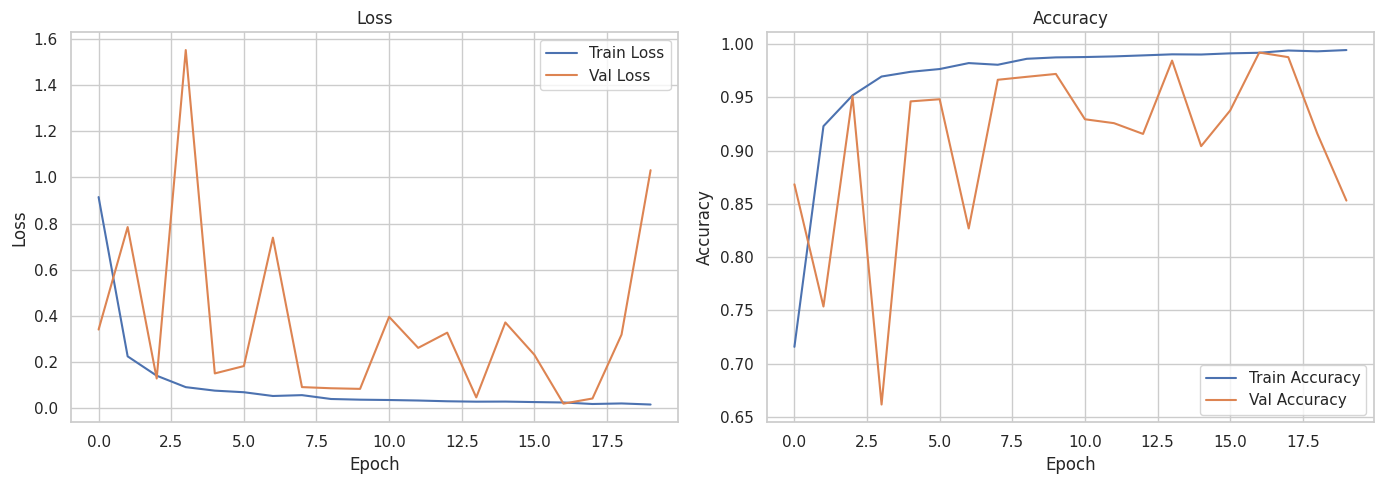

In [26]:
# ── Training curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
# ── Test set evaluation ──────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"\nWeighted F1 : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Macro F1    : {f1_score(y_test, y_pred, average='macro'):.4f}")

Test Loss     : 0.0322
Test Accuracy : 0.9882
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Weighted F1 : 0.9882
Macro F1    : 0.9881


In [28]:
# ── Classification Report ────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_
))


Classification Report:
              precision    recall  f1-score   support

        K001       1.00      1.00      1.00       420
        K002       1.00      1.00      1.00       360
        K003       0.98      0.90      0.94       360
        K004       0.93      0.97      0.95       360
        K005       0.98      1.00      0.99       360
        K006       0.90      0.98      0.94       360
        KA01       1.00      1.00      1.00       360
        KA03       0.98      0.98      0.98       360
        KA04       1.00      1.00      1.00       360
        KA05       0.99      1.00      1.00       360
        KA06       1.00      1.00      1.00       360
        KA07       1.00      0.99      1.00       360
        KA08       0.96      1.00      0.98       360
        KA09       1.00      1.00      1.00       360
        KA15       1.00      0.93      0.96       360
        KA16       1.00      1.00      1.00       360
        KA22       1.00      0.99      0.99       360
   

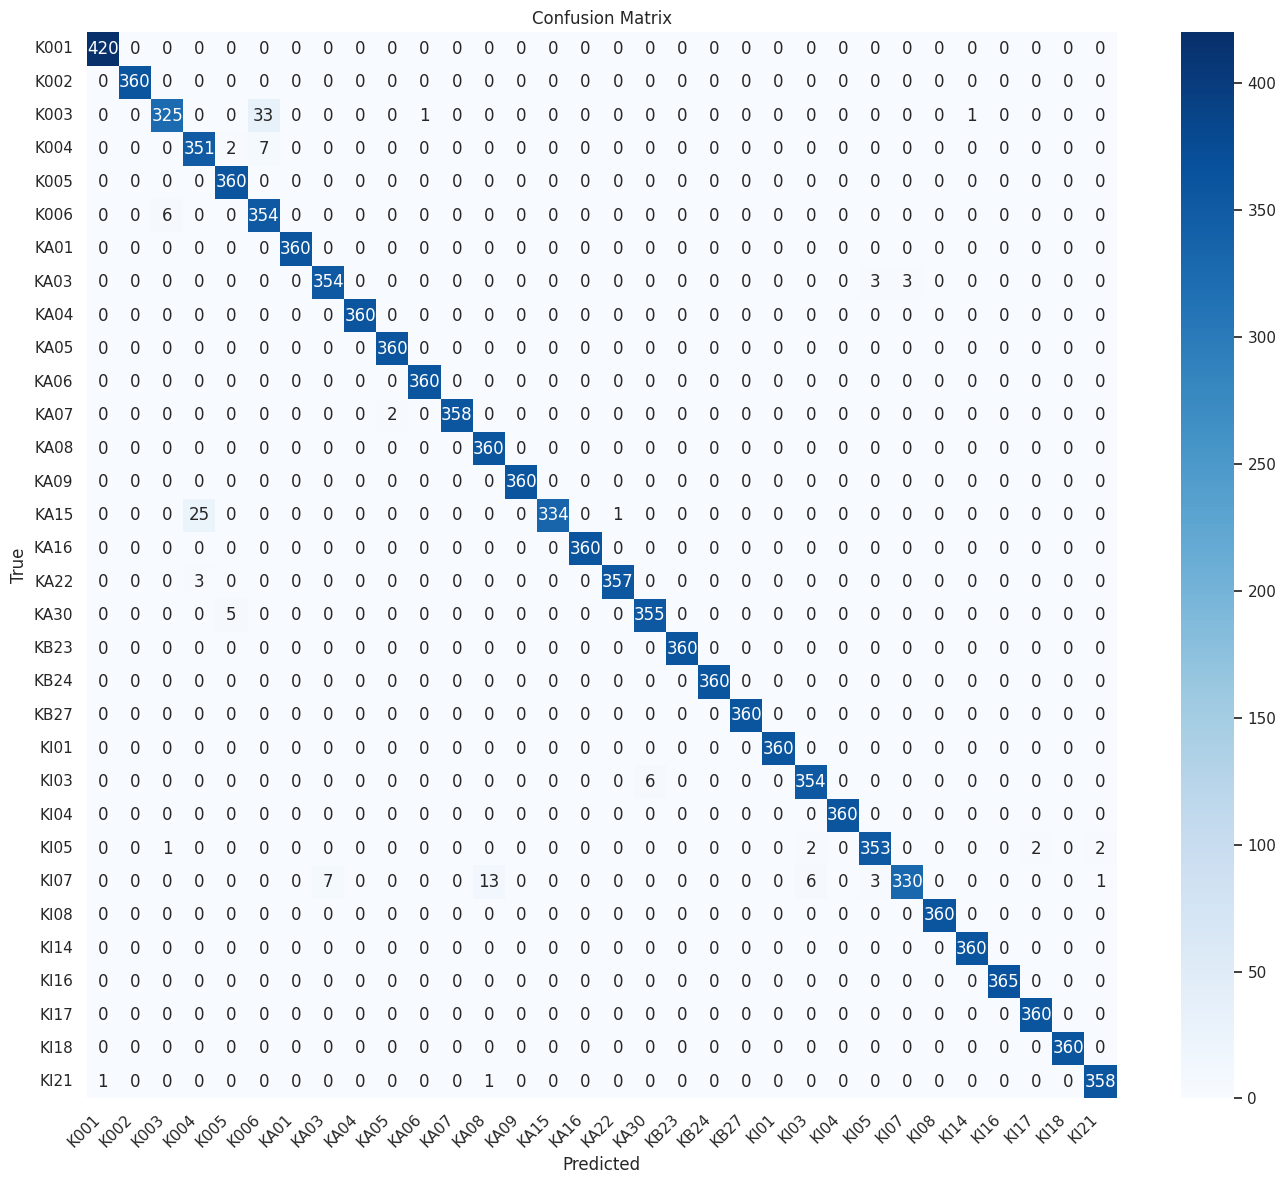

In [29]:
# ── Confusion Matrix ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()